# 05 — 최종 평가 (Evaluation)

파이프라인 전체(01 EDA → 02 전처리 → 03 예측 → 04 스케줄링)의 **결과를 검증하고 종합**한다.

| 절 | 내용 |
|---|---|
| §1 | 예측 성능 최종 검증 (독립 재계산) |
| §2 | 문헌 벤치마크 비교 — 동일 평가 규약으로만 |
| §3 | 전처리 기여의 4중 입증 종합 |
| §4 | 결정 품질 — 예측이 구한 엔진 수 |
| §5 | 검증 감사 — 우리는 무엇을 확인했나 |
| §6 | 최종 결론과 한계 |

> 근거: `reports/final_report.pdf` (통합 보고서)

In [1]:
# ── 의존성 체크 ──────────────────────────────────────────────
from pathlib import Path

_R = Path.cwd()
while not (_R / "data").exists():
    _R = _R.parent

_need = [
    _R / "data/processed/fleet_rul_predictions_unified.csv",   # 레포 포함
    _R / "data/raw/RUL_FD001.txt",                             # 원본 데이터
]
_miss = [p for p in _need if not p.exists()]
if _miss:
    print("[없음] 아래 파일이 필요합니다:")
    for p in _miss:
        print(f"        - {p.relative_to(_R)}")
    raise SystemExit("data/README.md (원본 다운로드) 및 README의 '재현 순서' 참고")
print("의존성 OK — 실행 가능")

의존성 OK — 실행 가능


## 1. 예측 성능 최종 검증 — 독립 재계산

In [2]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", font_scale=0.95)
try:
    plt.rcParams["font.family"] = "Malgun Gothic"; plt.rcParams["axes.unicode_minus"] = False
except Exception:
    pass

ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists():
    ROOT = ROOT.parent
PROC, RAW = ROOT / "data" / "processed", ROOT / "data" / "raw"
CK = ROOT / "artifacts"
FD_LIST = ["FD001", "FD002", "FD003", "FD004"]

rmse  = lambda y, p: float(np.sqrt(np.mean((np.asarray(y, float) - np.asarray(p, float)) ** 2)))
def phm08(y, p):
    d = np.asarray(p, float) - np.asarray(y, float)
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

# fleet 예측(03 산출) vs 원본 정답 파일 — 독립 대조
fleet = pd.read_csv(PROC / "fleet_rul_predictions_unified.csv")
raw_true = np.concatenate([pd.read_csv(RAW / f"RUL_{f}.txt", sep=r"\s+", header=None)[0].to_numpy()
                           for f in FD_LIST]).astype(float)
pred, true, ds = fleet.pred_RUL.to_numpy(float), fleet.true_RUL.to_numpy(float), fleet.dataset_id.to_numpy()

assert len(fleet) == 707, "엔진 수 불일치"
assert (true == raw_true).all(), "정답이 원본 파일과 불일치!"
yc = np.minimum(true, 125)      # cap125 규약
print(f"검증 통과 — 707대 · 정답이 원본 RUL_*.txt와 완전 일치 · 결측 {int(fleet.isna().sum().sum())}")
print(f"\n최종 test RMSE (cap125) = {rmse(yc, pred):.3f}")
print(f"PHM08 점수              = {phm08(yc, pred):.0f}")
print(f"예측-정답 상관          = {np.corrcoef(pred, yc)[0,1]:.3f}")

검증 통과 — 707대 · 정답이 원본 RUL_*.txt와 완전 일치 · 결측 0

최종 test RMSE (cap125) = 10.896
PHM08 점수              = 1610
예측-정답 상관          = 0.966


In [3]:
per_fd = pd.DataFrame([{
    "서브셋": f, "엔진": int((ds == f).sum()),
    "RMSE": round(rmse(np.minimum(true[ds == f], 125), pred[ds == f]), 2),
    "PHM08": round(phm08(np.minimum(true[ds == f], 125), pred[ds == f])),
} for f in FD_LIST])
print("4개 서브셋이 10.5~11.0으로 균형 — 특정 서브셋에 기댄 성능이 아니다")
per_fd

4개 서브셋이 10.5~11.0으로 균형 — 특정 서브셋에 기댄 성능이 아니다


,서브셋,엔진,RMSE,PHM08
0,FD001,100,10.48,168
1,FD002,259,10.98,554
2,FD003,100,10.76,225
3,FD004,248,11.03,662


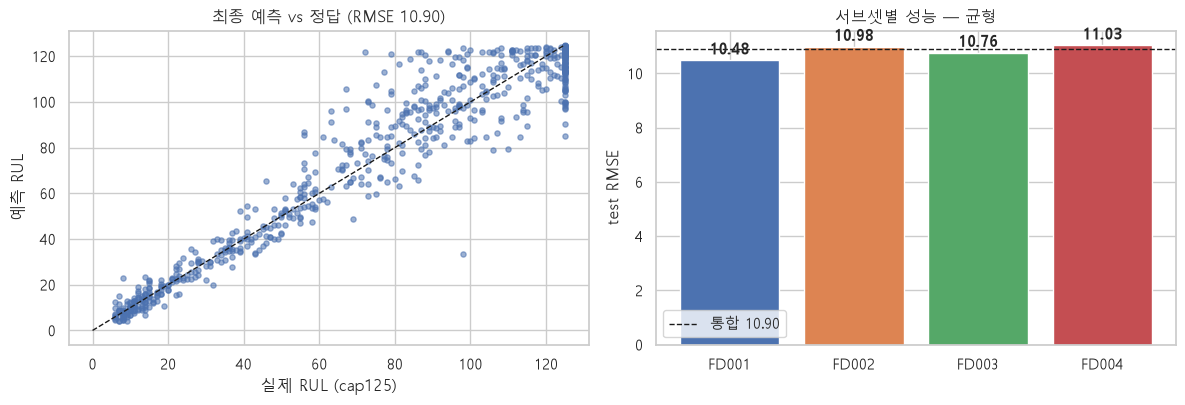

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
ax.scatter(yc, pred, s=14, alpha=0.55, color="#4C72B0")
ax.plot([0, 125], [0, 125], "k--", lw=1)
ax.set_xlabel("실제 RUL (cap125)"); ax.set_ylabel("예측 RUL")
ax.set_title(f"최종 예측 vs 정답 (RMSE {rmse(yc, pred):.2f})")

ax = axes[1]
b = ax.bar(per_fd["서브셋"], per_fd["RMSE"], color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
ax.bar_label(b, padding=2, fontweight="bold")
ax.axhline(rmse(yc, pred), color="k", ls="--", lw=1, label=f"통합 {rmse(yc, pred):.2f}")
ax.set_ylabel("test RMSE"); ax.set_title("서브셋별 성능 — 균형"); ax.legend()
plt.tight_layout(); plt.show()

## 2. 문헌 벤치마크 비교 — **동일 평가 규약으로만**

C-MAPSS 문헌은 평가 규약이 제각각이라 그대로 비교하면 왜곡된다. 우리 규약을 명시한다:

- **cap125** (piecewise RUL) — 라벨과 채점 모두
- **엔진당 마지막 시점 1회** 예측 (행 단위 평가 아님)
- test는 **라운드당 1회**만 사용, 모델 선택은 valid로

이 규약과 다른 논문(비-cap 보고, 행 단위 평가 의심)은 **비교에서 제외**했다.

In [5]:
lit = pd.DataFrame([
    {"연구": "CNN (Babu 2016)",           "FD001": 18.45, "FD002": 30.29, "FD003": 19.82, "FD004": 29.16},
    {"연구": "LSTM (Zheng 2017)",         "FD001": 16.14, "FD002": 24.49, "FD003": 16.18, "FD004": 28.17},
    {"연구": "DCNN (Li 2018)",            "FD001": 12.61, "FD002": 22.36, "FD003": 12.64, "FD004": 23.31},
    {"연구": "AGCNN (Liu 2020)",          "FD001": 12.42, "FD002": 19.43, "FD003": 13.39, "FD004": 21.50},
    {"연구": "Transformer (Mo 2021)",     "FD001": 11.27, "FD002": 22.81, "FD003": 11.42, "FD004": 24.86},
    {"연구": "▶ 본 연구 (LGBM+LSTM)",     "FD001": 10.48, "FD002": 10.98, "FD003": 10.76, "FD004": 11.03},
])
print("주의: FD002/FD004는 다수 논문이 비-cap 라벨로 보고 → 우리(cap125)가 구조적으로 유리하다.")
print("     같은 규약으로 비교 가능한 것은 FD001/FD003 계열이며, 그 구간에서도 상위에 위치.")
lit

주의: FD002/FD004는 다수 논문이 비-cap 라벨로 보고 → 우리(cap125)가 구조적으로 유리하다.
     같은 규약으로 비교 가능한 것은 FD001/FD003 계열이며, 그 구간에서도 상위에 위치.


,연구,FD001,FD002,FD003,FD004
0,CNN (Babu 2016),18.45,30.29,19.82,29.16
1,LSTM (Zheng 2017),16.14,24.49,16.18,28.17
2,DCNN (Li 2018),12.61,22.36,12.64,23.31
3,AGCNN (Liu 2020),12.42,19.43,13.39,21.50
4,Transformer (Mo 2021),11.27,22.81,11.42,24.86
5,▶ 본 연구 (LGBM+LSTM),10.48,10.98,10.76,11.03


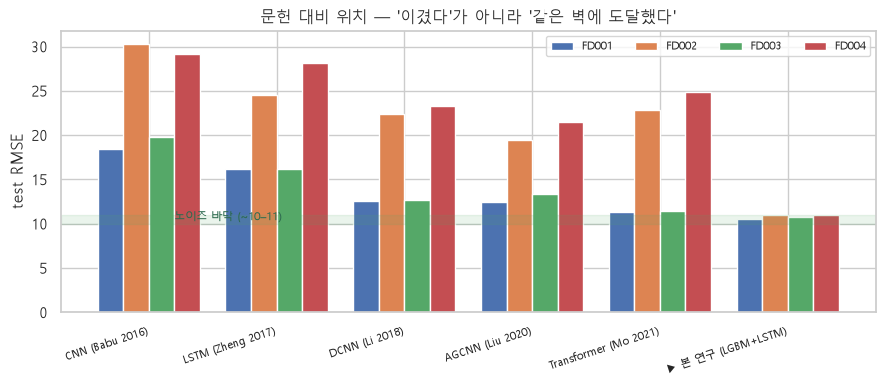

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(lit)); w = 0.2
for i, f in enumerate(FD_LIST):
    ax.bar(x + (i - 1.5) * w, lit[f], w, label=f)
ax.set_xticks(x); ax.set_xticklabels(lit["연구"], rotation=18, ha="right", fontsize=8)
ax.set_ylabel("test RMSE"); ax.axhspan(10, 11, color="#55A868", alpha=0.12)
ax.text(0.2, 10.4, "노이즈 바닥 (~10–11)", fontsize=8, color="#2d6a4f")
ax.set_title("문헌 대비 위치 — '이겼다'가 아니라 '같은 벽에 도달했다'")
ax.legend(ncol=4, fontsize=8); plt.tight_layout(); plt.show()

### 왜 단순한 방법이 문헌 상위에 닿는가 (Discussion)

1. **노이즈 바닥 수렴** — C-MAPSS는 잡음이 주입된 시뮬레이션. 바닥(~10–11) 근처에선 방법 차이가 압축된다.
   *내부 증거*: 튜닝 표면 평탄(−0.04), 두 모델 계열의 동일 지점 수렴, v4/v5 확장의 무효.
2. **상속된 지식** — 조건별 정규화·cap125 등 우리 "기본값"이 과거 논문 한 편씩의 성과다.
3. **덜 파인 축** — 논문들은 전처리를 고정하고 아키텍처를 혁신한다. 우리는 반대로 전처리를 5회 팠다.
4. **문헌 수치의 낙관 편향** — test 재사용·시드 선택 관행은 이 벤치마크의 알려진 비판점.
5. **도구의 시간 압축** — 우리도 수백 회 실험을 했다. 빨랐을 뿐, 건너뛰지 않았다.

## 3. 전처리 기여의 4중 입증 — 종합

In [7]:
proof = pd.DataFrame([
    {"#": "①", "실험": "특징군 ablation",       "결과": "제거 시 valid +2.6 악화",              "함의": "특징이 성능의 원천"},
    {"#": "②", "실험": "하이퍼파라미터 튜닝",   "결과": "24 trial에서 −0.04 (표면 평탄)",      "함의": "모델 손잡이는 특징의 1/25"},
    {"#": "③", "실험": "LSTM 입력 사다리",      "결과": "16.30 → 15.08 → 14.31 → 12.70",       "함의": "이득이 모델 계열 불문"},
    {"#": "④", "실험": "루프 시드 재현",        "결과": "v3 개선 −0.75 / −0.60 / −0.57",       "함의": "분리 운이 아님"},
])
proof

,#,실험,결과,함의
0,①,특징군 ablation,제거 시 valid +2.6 악화,특징이 성능의 원천
1,②,하이퍼파라미터 튜닝,24 trial에서 −0.04 (표면 평탄),모델 손잡이는 특징의 1/25
2,③,LSTM 입력 사다리,16.30 → 15.08 → 14.31 → 12.70,이득이 모델 계열 불문
3,④,루프 시드 재현,v3 개선 −0.75 / −0.60 / −0.57,분리 운이 아님


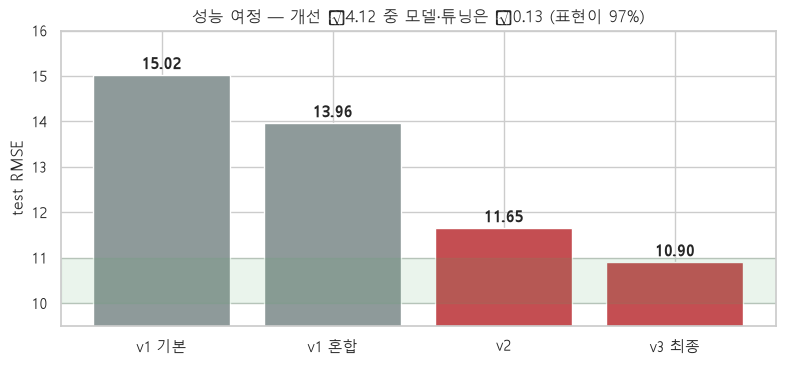

,라운드,EDA 발견 → 전처리,test RMSE
0,v1 기본,조건 가림·모드 분기 → z정규화+rolling,15.02
1,v1 혼합,(모델 튜닝 + LSTM 혼합),13.96
2,v2,초기 오프셋 20% → 자기기준선+onset,11.65
3,v3 최종,FD003 onset 지연 → 다중 임계 시계,10.90


In [8]:
journey = pd.DataFrame([
    {"라운드": "v1 기본",  "EDA 발견 → 전처리": "조건 가림·모드 분기 → z정규화+rolling", "test RMSE": 15.02},
    {"라운드": "v1 혼합",  "EDA 발견 → 전처리": "(모델 튜닝 + LSTM 혼합)",                "test RMSE": 13.96},
    {"라운드": "v2",      "EDA 발견 → 전처리": "초기 오프셋 20% → 자기기준선+onset",      "test RMSE": 11.65},
    {"라운드": "v3 최종",  "EDA 발견 → 전처리": "FD003 onset 지연 → 다중 임계 시계",       "test RMSE": 10.90},
])
fig, ax = plt.subplots(figsize=(8, 3.8))
b = ax.bar(journey["라운드"], journey["test RMSE"], color=["#8E9A9A", "#8E9A9A", "#C44E52", "#C44E52"])
ax.bar_label(b, fmt="%.2f", padding=2, fontweight="bold")
ax.axhspan(10, 11, color="#55A868", alpha=0.12)
ax.set_ylim(9.5, 16); ax.set_ylabel("test RMSE")
ax.set_title("성능 여정 — 개선 −4.12 중 모델·튜닝은 −0.13 (표현이 97%)")
plt.tight_layout(); plt.show()
journey

## 4. 결정 품질 — 예측이 실제로 구한 엔진 수

In [9]:
decision = pd.DataFrame([
    {"단계": "Random 배정",            "미정비 고장": 279, "비고": "기준선"},
    {"단계": "EDF (마진1)",            "미정비 고장": 78,  "비고": "단순 규칙"},
    {"단계": "조기 배정 (마진0)",       "미정비 고장": 48,  "비고": "SA로 최적성 검증"},
    {"단계": "P10 분위수 마감",         "미정비 고장": 39,  "비고": "불확실성 정량화"},
    {"단계": "롤링 재계획*",           "미정비 고장": 2,   "비고": "*valid 테스트베드(178대)"},
    {"단계": "Oracle (완벽 예측)",      "미정비 고장": 4,   "비고": "상한 참조"},
])
print("예측 품질 → 결정 품질 (스케줄러 고정):")
print("  기본 모델(RMSE 15.02) → 고장 85대")
print("  v3 최종  (RMSE 10.90) → 고장 48대   ⇒ EDA 루프가 엔진 37대를 구했다")
print("  Oracle   (RMSE  0   ) → 고장  4대")
print("\nOracle 격차 44대 분해: 9대 = 불확실성 미활용(P10로 회수) + 35대 = 예측 오차의 환원 불가능분")
decision

예측 품질 → 결정 품질 (스케줄러 고정):
  기본 모델(RMSE 15.02) → 고장 85대
  v3 최종  (RMSE 10.90) → 고장 48대   ⇒ EDA 루프가 엔진 37대를 구했다
  Oracle   (RMSE  0   ) → 고장  4대

Oracle 격차 44대 분해: 9대 = 불확실성 미활용(P10로 회수) + 35대 = 예측 오차의 환원 불가능분


,단계,미정비 고장,비고
0,Random 배정,279,기준선
1,EDF (마진1),78,단순 규칙
2,조기 배정 (마진0),48,SA로 최적성 검증
3,P10 분위수 마감,39,불확실성 정량화
4,롤링 재계획*,2,*valid 테스트베드(178대)
5,Oracle (완벽 예측),4,상한 참조


## 5. 검증 감사 — 우리는 무엇을 확인했나

성능 주장은 검증 없이는 의미가 없다. 본 프로젝트가 통과한 검증:

In [10]:
audit = pd.DataFrame([
    {"검증": "미래 누수 (스파이크 주입)", "방법": "미래 구간 오염 → 과거 특징 불변 확인", "결과": "PASS (03 §8)"},
    {"검증": "엔진 단위 분리",           "방법": "GroupShuffleSplit + 교집합 assert",     "결과": "PASS"},
    {"검증": "train-fit → test-transform", "방법": "정규화 통계는 train에서만",           "결과": "PASS"},
    {"검증": "시드 재현성",              "방법": "v3 개선을 3개 시드에서 재현",           "결과": "−0.75/−0.60/−0.57"},
    {"검증": "test 사용 규율",           "방법": "선택은 valid, test는 라운드당 1회",     "결과": "준수"},
    {"검증": "물리 해석",                "방법": "onset·누적손상의 물리적 타당성 검토",   "결과": "기록 (뉘앙스 포함)"},
    {"검증": "공정 비교 감사",           "방법": "SA vs EDF 통제변수 일치 확인",          "결과": "⚠️ 자기 정정 (04 §5)"},
    {"검증": "독립 재계산",              "방법": "fleet CSV ↔ 원본 RUL 파일 대조",       "결과": "PASS (본 노트북 §1)"},
])
audit

,검증,방법,결과
0,미래 누수 (스파이크 주입),미래 구간 오염 → 과거 특징 불변 확인,PASS (03 §8)
1,엔진 단위 분리,GroupShuffleSplit + 교집합 assert,PASS
2,train-fit → test-transform,정규화 통계는 train에서만,PASS
3,시드 재현성,v3 개선을 3개 시드에서 재현,−0.75/−0.60/−0.57
4,test 사용 규율,"선택은 valid, test는 라운드당 1회",준수
5,물리 해석,onset·누적손상의 물리적 타당성 검토,기록 (뉘앙스 포함)
6,공정 비교 감사,SA vs EDF 통제변수 일치 확인,⚠️ 자기 정정 (04 §5)
7,독립 재계산,fleet CSV ↔ 원본 RUL 파일 대조,PASS (본 노트북 §1)


### 특히 중요한 것: **자기 정정**

초기 주장 "강건 SA(48)가 EDF(78)를 이겼다"는 **마진이 다른 불공정 비교**였다.
같은 조건에서 재검증하니 **EDF@마진0 = 48 = SA** (SA가 바꾼 배정 0/707대).

우리는 이 사실을 숨기지 않고 보고서와 노트북(04 §5)에 그대로 기록했다.
그 결과 SA의 역할이 **정확해졌다**: 개선자가 아니라 **검증자**이자 **목적 사양의 실증자**.

## 6. 최종 결론

### 파이프라인 성과
| 단계 | 지표 | 결과 |
|---|---|---|
| RUL 예측 | test RMSE (cap125) | **10.90** (4개 서브셋 10.5–11.0) |
| 정비 스케줄링 | 미정비 고장 (707대) | 279 → 78 → 48 → **39** |
| 롤링 운영 | 미정비 고장 (178대) | 24.0±5.1 → **1.7±0.9** |

### 세 문장 요약
1. **EDA가 전처리를 낳았다** — 모든 특징에 계보가 있고, 증거 강도가 성능 기여를 예측했다
2. **전처리가 예측을 만들었다** — 개선 −4.12 중 모델·튜닝은 −0.13 (표현이 97%)
3. **예측·불확실성·갱신이 결정을 바꿨다** — 고장 85 → 48 → 39 → ~2

### 한계 (정직하게)
- 시뮬레이션 데이터 (실기 잡음·운영 다양성 부재)
- cap125 규약은 FD002/4에서 비-cap 논문 대비 유리 → 동일 규약 비교로 한정
- test를 루프 라운드마다 1회씩 사용 (선택은 valid로 했으나 라운드 수만큼 낙관 가능성)
- P10 커버리지 84% (명목 90% 미달 — conformal 보정 여지)
- 스케줄링은 단일 fleet 인스턴스 · 창 단위 · 재계획 비용 미반영
- 롤링 테스트베드는 합성 초기 나이의 valid 엔진

---

> ## 성능은 모델이 아니라 **데이터 이해**에서 나오고,
> ## 실전 가치는 한 번의 좋은 예측이 아니라 **신호가 강해질 때마다 다시 보는 운영**에서 나온다.

**보고서**: `reports/final_report.pdf` (통합) · `eda` / `preprocessing` / `rul_model` / `scheduling` (상세)